# 📘 CIFAR-10 Image Classification Learning Project
## Build and Compare **ANN vs CNN** on CIFAR-10

This notebook is designed for **students and beginners** to learn:
- How image classification works
- Why **CNN performs better than ANN**
- How architecture impacts performance
- How training strategies improve results

🎯 **Learning Goal:** Understand the complete DL pipeline by **reading the markdown + running the ready code**.

# 🧠 Problem Statement
Build an image classification model on the **CIFAR-10 dataset** using:

1. **Artificial Neural Network (ANN)**
2. **Convolutional Neural Network (CNN)**

Then compare:
- Accuracy
- Loss curves
- Generalization
- Training strategies (dropout, batch norm, augmentation)

---
### 📦 CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


# 📥 Load Dataset
We use **CIFAR-10**, which contains **60,000 color images of size 32×32×3**.
- 50,000 training images
- 10,000 test images

In [ ]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1644s 10us/step
Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


## 🖼️ Visualize Sample Images

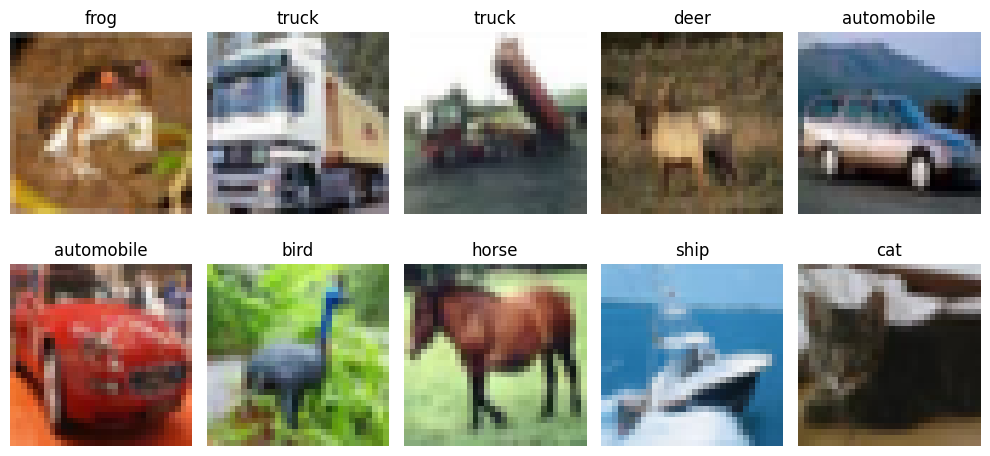

In [ ]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

# 🧹 Preprocessing
We normalize pixel values from **0–255 → 0–1** so training becomes stable.

In [ ]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

# 🔹 Part 1: ANN Model
ANN treats images as **flat vectors**, so it cannot preserve spatial features.
This helps students understand **why CNN is better for images**.

In [ ]:
ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 19ms/step - accuracy: 0.2671 - loss: 2.0007 - val_accuracy: 0.3136 - val_loss: 1.8478
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 18ms/step - accuracy: 0.3152 - loss: 1.8737 - val_accuracy: 0.3608 - val_loss: 1.7884
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 12s 18ms/step - accuracy: 0.3334 - loss: 1.8171 - val_accuracy: 0.3714 - val_loss: 1.7526
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 13s 18ms/step - accuracy: 0.3452 - loss: 1.7947 - val_accuracy: 0.3874 - val_loss: 1.7292
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 13s 18ms/step - accuracy: 0.3568 - loss: 1.7695 - val_accuracy: 0.3932 - val_loss: 1.7099
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 19ms/step - accuracy: 0.3675 - loss: 1.7420 - val_accuracy: 0.4036 - val_loss: 1.6944
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 20ms/step - accuracy: 0.3759 - loss: 1.7219 - val_accuracy: 0.3942 - val_loss: 1.7183
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 12s 18ms/step - accuracy: 0.3800 - loss: 1.7060 - 

In [ ]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4348 - loss: 1.6322
ANN Test Accuracy: 0.43479999899864197


Now in our ANN MODEL let see what happen when we increase layers and add batch normalization and increase number of epochs.

In [ ]:
ann_model = models.Sequential([

      layers.Input(shape=(3072,)),

      layers.Dense(512),
      layers.BatchNormalization(),
      layers.Activation('relu'),
      layers.Dropout(0.3),

      layers.Dense(256),
      layers.BatchNormalization(),
      layers.Activation('relu'),
      layers.Dropout(0.3),

      layers.Dense(128),
      layers.BatchNormalization(),
      layers.Activation('relu'),
      layers.Dropout(0.2),

      layers.Dense(10, activation='softmax')
      ])




In [ ]:
ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
      monitor='val_loss',
      patience=5,
      restore_best_weights=True
)

In [ ]:
history = ann_model.fit(
      x_train_flat,
      y_train,
      epochs=50,
      batch_size=128,
      validation_split=0.2,
      callbacks=[early_stop],
      verbose=1
)


Epoch 1/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 32ms/step - accuracy: 0.3431 - loss: 1.8397 - val_accuracy: 0.3297 - val_loss: 1.8261
Epoch 2/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 28ms/step - accuracy: 0.4255 - loss: 1.6117 - val_accuracy: 0.3406 - val_loss: 1.8137
Epoch 3/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/step - accuracy: 0.4531 - loss: 1.5221 - val_accuracy: 0.4185 - val_loss: 1.6413
Epoch 4/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/step - accuracy: 0.4785 - loss: 1.4620 - val_accuracy: 0.3868 - val_loss: 1.7237
Epoch 5/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/step - accuracy: 0.4989 - loss: 1.4089 - val_accuracy: 0.4622 - val_loss: 1.5288
Epoch 6/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 32ms/step - accuracy: 0.5077 - loss: 1.3716 - val_accuracy: 0.4210 - val_loss: 1.5893
Epoch 7/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 33ms/step - accuracy: 0.5218 - loss: 1.3345 - val_accuracy: 0.4320 - val_loss: 1.5802
Epoch 8/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 32ms/step - accuracy: 0.5351 - loss: 1.2979 - v

In [ ]:
loss, accuracy = ann_model.evaluate(
      x_test_flat,
      y_test,
      verbose=0
)

print("Test Accuracy:", accuracy)

Test Accuracy: 0.4952999949455261


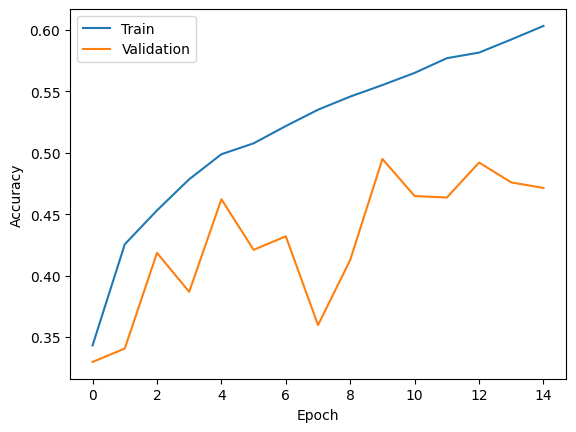

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train','Validation'])

plt.show()

after Batch normalization problem of internal covariate shift has reduced , it reduces this problem by standardizing the activations.

Dropout = regularization technique used to prevent overfitting by randomly deactivating a fraction of neurons during training.
0.3 and like 0.2 means 30% and 20% neurons randomly turned off. which help in the reducing overfitting .

Early Stopping = Early Stopping is a technique that automatically stops training when the model stops improving on the validation dataset.
->it is needed because when training accuracy increase validation accuracy decreses then model begins to overfit.
-> In our model training stop at approximately epoch 15 because the validation loss stopped improving .

By doing increment layers , batch normalization , dropout , early stopping we are able to increase the accuracy from the 43 to 49 percent .

i have tried using only dropout at last layer because by learning i know that first dropout we should do on last layer but it losses the accuracy and goes to 41 percent it is because when i see that after flatten the neurons the first hidden layer i made is of 1024 neurons which make model to complex and we know that neural network are complex and prone to overfitting so the reason behind reducing the accuracy is overfitting .


After all this we know ANN is not good for image type of data because it always fails on capturing the spatial features of the images.

So this give rise to CNN architecture which is more suitable for images .

# 🔹 Part 2: CNN Model
CNN preserves **spatial relationships** using:
- Convolution layers
- Pooling
- Feature extraction
- Hierarchical learning

This is why CNN performs much better for image tasks.

In [ ]:
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 59s 80ms/step - accuracy: 0.4626 - loss: 1.5082 - val_accuracy: 0.5570 - val_loss: 1.2548
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 56s 80ms/step - accuracy: 0.5976 - loss: 1.1505 - val_accuracy: 0.5176 - val_loss: 1.3710
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 56s 79ms/step - accuracy: 0.6634 - loss: 0.9670 - val_accuracy: 0.5290 - val_loss: 1.4633
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 55s 78ms/step - accuracy: 0.7033 - loss: 0.8560 - val_accuracy: 0.6536 - val_loss: 0.9976
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 55s 78ms/step - accuracy: 0.7368 - loss: 0.7560 - val_accuracy: 0.6738 - val_loss: 0.9765
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 55s 79ms/step - accuracy: 0.7584 - loss: 0.6834 - val_accuracy: 0.7042 - val_loss: 0.9116
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 53s 75ms/step - accuracy: 0.7848 - loss: 0.6111 - val_accuracy: 0.6494 - val_loss: 1.0498
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 55s 79ms/step - accuracy: 0.8062 - loss: 0.5479 - 

In [ ]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.6848 - loss: 1.0803
CNN Test Accuracy: 0.6848000288009644


## 📈 Compare Learning Curves

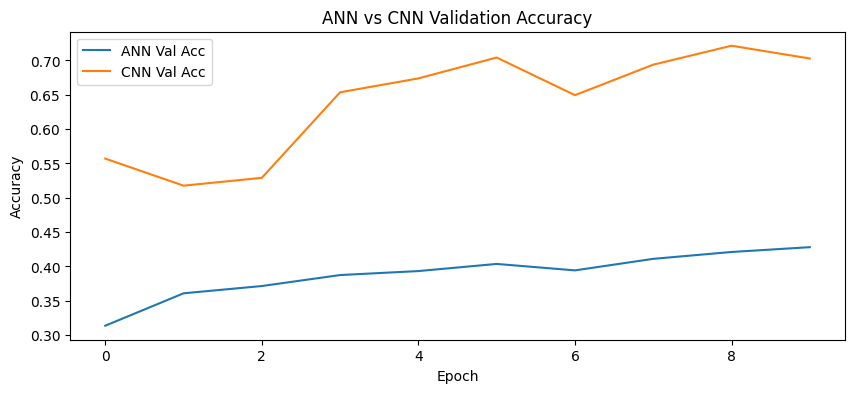

In [ ]:
plt.figure(figsize=(10,4))
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs CNN Validation Accuracy")
plt.legend()
plt.show()

# 🚀 Training Strategy Upgrade: Data Augmentation
This strategy improves generalization by generating transformed images.

In [ ]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

aug_cnn_model = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, 3, activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

# Suggested optional run:
# aug_history = aug_cnn_model.fit(x_train_norm, y_train, epochs=10, validation_split=0.1)

# 📊 Final Comparison Table

In [ ]:
comparison = pd.DataFrame({
    "Model": ["ANN", "CNN"],
    "Test Accuracy": [ann_test_acc, cnn_test_acc]
})
comparison

,Model,Test Accuracy
0,ANN,0.4348
1,CNN,0.6848


In [ ]:
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow as tf

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])


cnn_model = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, (3,3), padding='same', activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(128, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),

    layers.Dense(10, activation='softmax')
])


cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)


cnn_history = cnn_model.fit(
    x_train_norm,
    y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 267s 372ms/step - accuracy: 0.3120 - loss: 1.8991 - val_accuracy: 0.4396 - val_loss: 1.5824
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 256s 363ms/step - accuracy: 0.4588 - loss: 1.5085 - val_accuracy: 0.5110 - val_loss: 1.3789
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 255s 362ms/step - accuracy: 0.5234 - loss: 1.3576 - val_accuracy: 0.5036 - val_loss: 1.5008
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 259s 368ms/step - accuracy: 0.5732 - loss: 1.2360 - val_accuracy: 0.5786 - val_loss: 1.2046
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 267s 376ms/step - accuracy: 0.6151 - loss: 1.1332 - val_accuracy: 0.6278 - val_loss: 1.0566
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 324s 379ms/step - accuracy: 0.6388 - loss: 1.0707 - val_accuracy: 0.6644 - val_loss: 0.9757
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 327s 386ms/step - accuracy: 0.6653 - loss: 1.0051 - val_accuracy: 0.6960 - val_loss: 0.9107
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 321s 385ms/step - accuracy: 0.6832 -

In [ ]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(
      x_test_norm,
      y_test,
      verbose=0
)

print("CNN Test Accuracy:", cnn_test_acc)


CNN Test Accuracy: 0.7950000166893005


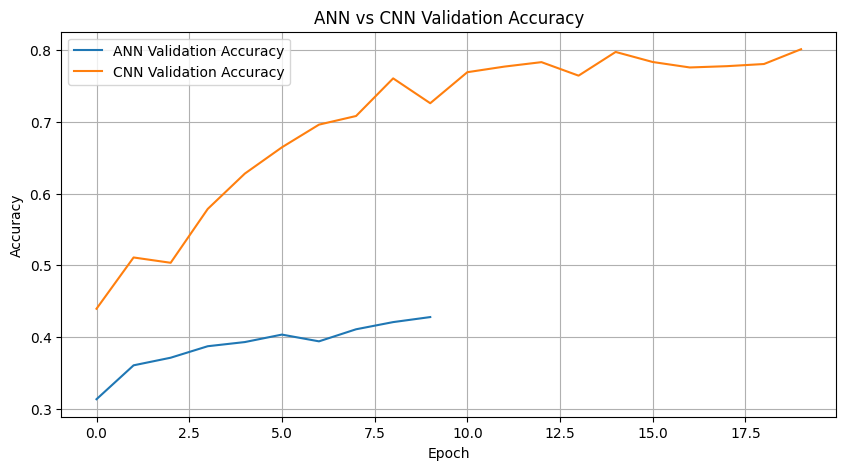

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(
    ann_history.history['val_accuracy'],
    label='ANN Validation Accuracy'
)

plt.plot(
    cnn_history.history['val_accuracy'],
    label='CNN Validation Accuracy'
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs CNN Validation Accuracy")
plt.legend()
plt.grid(True)

plt.show()

# 🎓 Student Learning Tasks
Try these tasks after understanding the notebook:

### ✅ Beginner Tasks
1. Increase ANN layers and observe performance
2. Change CNN filters from 32→64→128
3. Increase epochs to 20
4. Add **EarlyStopping**
5. Add **data augmentation training**

# ✅ Conclusion
- **ANN works**, but ignores image structure
- **CNN extracts spatial features**, so it performs significantly better
- **Training strategies** like dropout, batch norm, and augmentation improve results
- This project builds strong fundamentals for **computer vision interviews and deep learning projects**